# Face Detector Workflow (PyTorch) — Fixed
This notebook sets up a training/visualization workflow for WIDER FACE (SSD-style implementation).


## 1. Setup & Installation
Install minimal dependencies. We use the **headless** OpenCV wheel for server/GUI-less environments.


In [2]:
!pip install -q opencv-python-headless


In [1]:
import torch
import torch.optim as optim
import torch.utils.data as data
from torch.optim.lr_scheduler import MultiStepLR
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time
import os

# Project-specific modules (ensure these paths exist in your repo)
from config.config import ssd_cfg, WIDERFACE_DIR, CHECKPOINT_DIR
from data.dataset import WiderFaceDataset, detection_collate
from data import transforms
from models.ssd import SSD
from models.loss import MultiBoxLoss
from utils.visualize import draw_boxes_and_labels

print("Torch:", torch.__version__)
print("OpenCV:", cv2.__version__)


Torch: 2.7.1+cpu
OpenCV: 4.12.0


## 2. Configuration
Key hyperparameters and training options.


In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 8
EPOCHS = 50
INIT_LR = 1e-3
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
LR_DECAY_EPOCHS = [30, 40]
LR_DECAY_GAMMA = 0.1
NUM_WORKERS = 2
PIN_MEMORY = True
MATCH_THRESH = 0.5
NEG_POS_RATIO = 3

print(f"Device: {DEVICE}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")


Device: cpu
Batch Size: 8
Epochs: 50


## 3. Data Loading & Augmentation
We define a light augmentation pipeline (using the project's `data.transforms`) and create the training dataloader.


In [3]:
class Augmentation(object):
    def __init__(self, size=300, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
        self.mean = mean
        self.size = size
        self.std = std
        self.augment = transforms.Compose([
            transforms.RandomContrast(),
            transforms.ConvertColor(transform="HSV"),
            transforms.RandomBrightness(),
            transforms.ConvertColor(current="HSV", transform="BGR"),
            transforms.RandomHorizontalFlip(),
            transforms.RandomSampleCrop(),
            transforms.Resize(self.size),
            transforms.Normalize(self.mean, self.std),
            transforms.ToTensor()
        ])

    def __call__(self, img, target):
        return self.augment(img, target)

train_annot_path = WIDERFACE_DIR / "wider_face_split" / "wider_face_train_bbx_gt.txt"
train_dataset = WiderFaceDataset(txt_path=train_annot_path, preproc=Augmentation(size=ssd_cfg["input_size"]))

train_loader = data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    collate_fn=detection_collate,
    pin_memory=PIN_MEMORY,
)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Number of training batches: {len(train_loader)}")


Training dataset size: 12880
Number of training batches: 1610


### Visualize a Data Sample (Before Augmentation)
We load one un-augmented example and draw the original bounding boxes for a quick sanity check.


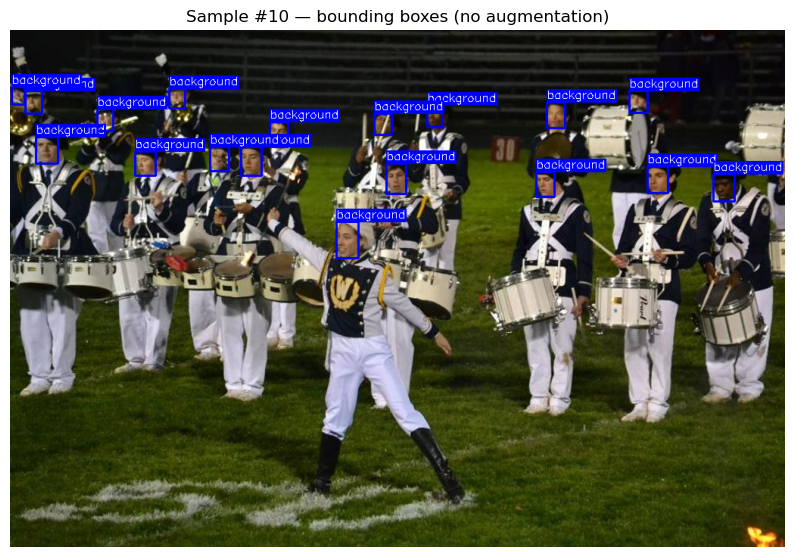

In [13]:
# Use a no-preprocessing dataset to inspect raw annotations
viz_dataset = WiderFaceDataset(txt_path=train_annot_path, preproc=None)
image, annotations = viz_dataset[40]  # pick an arbitrary index

# annotations expected format: [x1, y1, x2, y2, label] per row
boxes = annotations[:, :4]
labels = annotations[:, 4]

img_with_boxes = draw_boxes_and_labels(image, boxes, labels, class_names=["background", "face"])

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
plt.title("Sample #10 — bounding boxes (no augmentation)")
plt.axis("off")
plt.show()


In [14]:

# Sanity imports
import torch, os, cv2, numpy as np
from pathlib import Path

from config.config import (
    ssd_cfg, WIDERFACE_DIR, CHECKPOINT_DIR, DEVICE, BATCH_SIZE, 
    INIT_LR, MOMENTUM, WEIGHT_DECAY, LR_DECAY_EPOCHS, LR_DECAY_GAMMA,
    MATCH_THRESH, NEG_POS_RATIO, EPOCHS
)
from data.dataset import WiderFaceDataset, detection_collate
from data.transforms import Compose, Normalize, ToTensor, Resize
from models.ssd import SSD
from models.loss import MultiBoxLoss

print("DEVICE:", DEVICE)
print("WIDERFACE_DIR exists:", Path(WIDERFACE_DIR).exists())
print("CHECKPOINT_DIR:", CHECKPOINT_DIR)


DEVICE: cpu
WIDERFACE_DIR exists: True
CHECKPOINT_DIR: /home/jovyan/work/face_detector/checkpoints


In [15]:

# Build a small dataloader for a quick sanity check (no augmentation, just resize/normalize)
transform = Compose([
    Resize(ssd_cfg['input_size']),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensor()
])

train_annot_path = Path(WIDERFACE_DIR) / 'wider_face_split' / 'wider_face_train_bbx_gt.txt'
ds = WiderFaceDataset(txt_path=train_annot_path, preproc=transform)
print("Train images:", len(ds))

from torch.utils.data import DataLoader
loader = DataLoader(ds, batch_size=2, shuffle=True, num_workers=0, collate_fn=detection_collate)

batch = next(iter(loader))
imgs, targets = batch
print("Batch image tensor shape:", imgs.shape)
print("Targets[0] shape:", targets[0].shape if len(targets)>0 else None)


Train images: 12880
Batch image tensor shape: torch.Size([2, 3, 300, 300])
Targets[0] shape: torch.Size([2, 5])


In [7]:

from scripts.train import run_training

# Uncomment to run training here (will take time):
run_training()
print("Training hook ready (call run_training()).")


Starting training...
Training on cuda
Epoch [1/150] || iter 50/805 || Loss: 9.8324 (L: 7.0371, C: 2.7953)
Epoch [1/150] || iter 100/805 || Loss: 12.6255 (L: 9.8417, C: 2.7838)
Epoch [1/150] || iter 150/805 || Loss: 10.4048 (L: 7.6311, C: 2.7737)
Epoch [1/150] || iter 200/805 || Loss: 15.8585 (L: 13.0973, C: 2.7612)
Epoch [1/150] || iter 250/805 || Loss: 16.1290 (L: 13.3784, C: 2.7506)
Epoch [1/150] || iter 300/805 || Loss: 18.7769 (L: 16.0380, C: 2.7389)
Epoch [1/150] || iter 350/805 || Loss: 8.3104 (L: 5.5827, C: 2.7277)
Epoch [1/150] || iter 400/805 || Loss: 8.5985 (L: 5.8839, C: 2.7146)
Epoch [1/150] || iter 450/805 || Loss: 6.2015 (L: 3.5008, C: 2.7006)
Epoch [1/150] || iter 500/805 || Loss: 7.1517 (L: 4.4619, C: 2.6898)
Epoch [1/150] || iter 550/805 || Loss: 7.6041 (L: 4.8300, C: 2.7741)
Epoch [1/150] || iter 600/805 || Loss: 9.6369 (L: 6.9700, C: 2.6670)
Epoch [1/150] || iter 650/805 || Loss: 7.5625 (L: 4.8653, C: 2.6972)
Epoch [1/150] || iter 700/805 || Loss: 9.0077 (L: 6.2675, 

KeyboardInterrupt: 

In [7]:

from scripts.evaluate import evaluate

# Example: build a tiny loader (already built above as `loader`) and a fresh model for shape test
device = torch.device(DEVICE)
model = SSD(num_classes=ssd_cfg['num_classes'], size=ssd_cfg['input_size'], cfg=ssd_cfg).to(device)

# NOTE: load your trained weights before real evaluation:
model.load_state_dict(torch.load(Path(CHECKPOINT_DIR)/'ssd300_epoch_10.pth', map_location=device))

evaluate(model, loader, device)  # mAP stub prints a message
print("Eval hook ready (call evaluate(model, loader, device)).")


KeyboardInterrupt: 

In [16]:
# --- Single-image Face Detection & Drawing ---

import cv2
import torch
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from time import time

from config.config import ssd_cfg, DEVICE, VARIANCES, OUTPUTS_DIR, CHECKPOINT_DIR
from models.ssd import SSD
from utils.box_utils import decode, nms

# 설정
FACE_CLS_IDX = 1           # background=0, face=1
CONF_THRESH = 0.5          # 자신감 임계치 (조절 가능: 0.3~0.7)
NMS_THRESH  = 0.45         # NMS IoU 임계치
TOP_K       = 200          # NMS 이후 최대 보존 박스 수

# 전처리 (학습과 동일한 Normalize만 적용)
def preprocess_bgr(img_bgr, size=ssd_cfg['input_size']):
    img = cv2.resize(img_bgr, (size, size))
    img = img.astype(np.float32) / 255.0
    img -= np.array([0.485, 0.456, 0.406], dtype=np.float32)
    img /= np.array([0.229, 0.224, 0.225], dtype=np.float32)
    # HWC -> CHW
    img = img.transpose(2, 0, 1)
    return torch.from_numpy(img).unsqueeze(0)  # [1,3,H,W]

def draw_detections(img_bgr, boxes_xyxy, scores, label='face'):
    out = img_bgr.copy()
    for (x1, y1, x2, y2), sc in zip(boxes_xyxy, scores):
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        cv2.rectangle(out, (x1, y1), (x2, y2), (0, 200, 0), 2)
        txt = f"{label}: {sc:.2f}"
        (tw, th), bl = cv2.getTextSize(txt, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
        cv2.rectangle(out, (x1, y1 - th - 6), (x1 + tw + 2, y1), (0, 200, 0), -1)
        cv2.putText(out, txt, (x1 + 1, y1 - 4), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,0), 1, cv2.LINE_AA)
    return out

@torch.inference_mode()
def detect_faces_on_image(image_path, weights_path=None, device=torch.device(DEVICE)):
    # 이미지 로드
    img_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise FileNotFoundError(f"Image not found: {image_path}")
    H, W = img_bgr.shape[:2]

    # 모델 준비
    model = SSD(num_classes=ssd_cfg['num_classes'], size=ssd_cfg['input_size'], cfg=ssd_cfg).to(device)
    if weights_path is None:
        # 최신 체크포인트가 있으면 자동으로 선택
        ckpts = sorted(Path(CHECKPOINT_DIR).glob("ssd300_epoch_*.pth"))
        if not ckpts:
            raise FileNotFoundError("No weights found in CHECKPOINT_DIR. Provide weights_path.")
        weights_path = ckpts[-1]
    model.load_state_dict(torch.load(str(weights_path), map_location=device))
    model.eval()

    # 전처리 & 추론
    inp = preprocess_bgr(img_bgr).to(device, non_blocking=True)
    t0 = time()
    loc, conf, priors = model(inp)
    infer_ms = (time() - t0) * 1000

    # 디코드(0~1 스케일) & 스코어 계산
    priors = priors.to(device)
    boxes = decode(loc[0], priors, VARIANCES).clamp_(0, 1)     # [num_priors,4] in 0~1
    probs = torch.softmax(conf[0], dim=-1)                     # [num_priors,num_classes]
    scores = probs[:, FACE_CLS_IDX]

    # 임계치 필터 + NMS
    keep_mask = scores > CONF_THRESH
    if keep_mask.any():
        bxs = boxes[keep_mask]
        scs = scores[keep_mask]
        res = nms(bxs, scs, overlap=NMS_THRESH, top_k=TOP_K)
        # (keep, count) 또는 keep 텐서 대응
        if isinstance(res, tuple):
            keep_idx, count = res
            keep_idx = keep_idx[:count]
        else:
            keep_idx = res
        keep_idx = torch.as_tensor(keep_idx, device=bxs.device, dtype=torch.long).view(-1)
        if keep_idx.numel() > 0:
            bxs = bxs.index_select(0, keep_idx).detach().cpu().numpy()
            scs = scs.index_select(0, keep_idx).detach().cpu().numpy()
        else:
            bxs = np.zeros((0, 4), dtype=np.float32)
            scs = np.zeros((0,), dtype=np.float32)
    else:
        bxs = np.zeros((0, 4), dtype=np.float32)
        scs = np.zeros((0,), dtype=np.float32)

    # 원본 해상도로 스케일링
    if bxs.shape[0] > 0:
        bxs[:, [0, 2]] *= W
        bxs[:, [1, 3]] *= H

    # 그리기 & 저장/표시
    vis = draw_detections(img_bgr, bxs, scs, label='face')

    out_dir = Path(OUTPUTS_DIR)
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / (Path(image_path).stem + "_det.jpg")
    cv2.imwrite(str(out_path), vis)

    print(f"Detections: {len(scs)} | infer: {infer_ms:.1f} ms | saved: {out_path}")
    # 노트북에서 바로 보기 (matplotlib은 RGB)
    plt.figure(figsize=(10,10))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    return bxs, scs, str(out_path)

# ----------------- 사용 예시 -----------------
# img_path = "/path/to/your/image.jpg"
# _ = detect_faces_on_image(img_path, weights_path=Path(CHECKPOINT_DIR)/"ssd300_epoch_10.pth")


Detections: 0 | infer: 1399.9 ms | saved: /home/jovyan/work/face_detector/outputs/12_Group_Team_Organized_Group_12_Group_Team_Organized_Group_12_1018_det.jpg


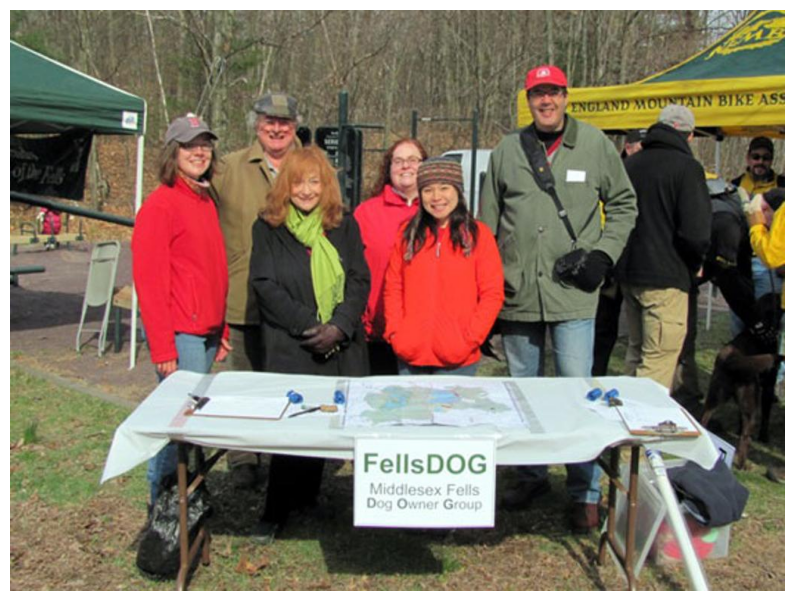

In [17]:
_ = detect_faces_on_image(
    "widerface/WIDER_test/images/12--Group/12_Group_Team_Organized_Group_12_Group_Team_Organized_Group_12_1018.jpg",
    weights_path=Path(CHECKPOINT_DIR)/"ssd300_epoch_10.pth"  # 생략하면 CHECKPOINT_DIR에서 최신 ckpt 자동 선택
)